In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Obj1. Load and preprocess the dataset
data = pd.read_csv("data.csv")
print(data.head(5))

if data.isnull().sum().any():
    data = data.dropna()

X = data.iloc[:, :11].values
y = data.iloc[:, 11].values

X = np.c_[np.ones(X.shape[0]), X] #(Adding a column of ones)


   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030           1.0            3.0         3.0      1967.0   
1   2   287.678577           1.0            2.0         1.0      1949.0   
2   3   232.998485           1.0            3.0         2.0      1923.0   
3   4   199.664621           5.0            2.0         2.0      1918.0   
4   5    89.004660           4.0            3.0         3.0      1999.0   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0         1.0       1.0         48.0        8.297631            5.935734   
1         0.0       1.0         37.0        6.061466           10.827392   
2         1.0       0.0         14.0        2.911442            6.904599   
3         0.0       0.0         17.0        2.070949            8.284019   
4         1.0       0.0         34.0        1.523278           14.648277   

   Price  
0   6021  
1   5914  
2   4645  
3   5831  
4   6199  


In [3]:
# Obj2. Perform exploratory data analysis
print("\nDataset description:")
print(data.describe())



Dataset description:
               ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
count  470.000000   470.000000    470.000000     470.000000  470.000000   
mean   250.957447   174.752030      2.959574       1.987234    1.965957   
std    146.115729    75.427674      1.447173       0.818136    0.807026   
min      1.000000    51.380529      1.000000       1.000000    1.000000   
25%    124.250000   107.727724      2.000000       1.000000    1.000000   
50%    252.500000   178.290937      3.000000       2.000000    2.000000   
75%    378.750000   240.332309      4.000000       3.000000    3.000000   
max    500.000000   298.241199      5.000000       3.000000    3.000000   

        Year_Built  Has_Garden    Has_Pool  Garage_Size  Location_Score  \
count   470.000000  470.000000  470.000000   470.000000      470.000000   
mean   1958.317021    0.538298    0.489362    30.165957        5.166682   
std      35.175277    0.499062    0.500419    11.615468        2.857326   
mi

In [4]:

#Obj3. Linear Regression using Matrix-based Method
beta = np.linalg.inv(X.T @ X) @ X.T @ y  # Calculate weights

# predicting......
ypred = X @ beta



Model Performance:
Mean Squared Error : 35864.95
Residual Sum of Squares : 16856524.70


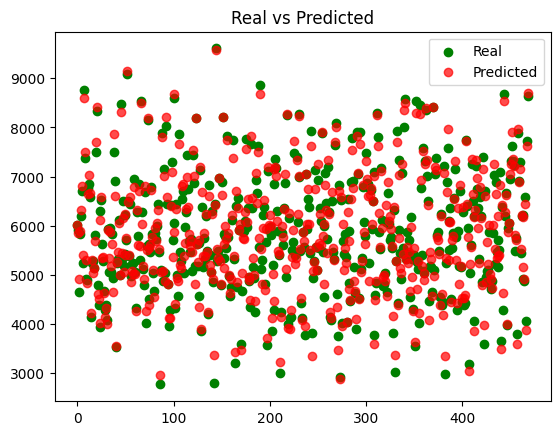

In [5]:

#Obj4. Evaluat the Model

mse = np.mean((y - ypred)**2)
rss = np.sum((y - ypred)**2)

print("\nModel Performance:")
print(f"Mean Squared Error : {mse:.2f}")
print(f"Residual Sum of Squares : {rss:.2f}")

# PlotTING real vs predicted graph
plt.scatter(range(len(y)), y, color="green", label="Real")
plt.scatter(range(len(y)), ypred, color="red", label="Predicted", alpha=0.7)
plt.title("Real vs Predicted")
plt.legend()
plt.show()